# SRL-NER Sirah — S2a (SCL — Strict Supervised Contrastive Learning)

# BERT Percobaan 1 (35% train and 65% unlabelled)

## Install dependency

In [ ]:
# Colab sudah punya transformers/datasets/torch — cukup upgrade
!pip install -q -U transformers accelerate seaborn seqeval


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 162.2 MB/s eta 0:00:00


In [ ]:
pip install tqdm -q

In [ ]:
pip install -U accelerate>=0.21.0' -q

/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [ ]:
pip install -U transformers[torch] -q

In [ ]:
pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.3 MB/s eta 0:00:00


In [ ]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, TrainingArguments, Trainer, DataCollatorForTokenClassification, AutoModelForTokenClassification, pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from shutil import rmtree
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import os

# seqeval = entity-level NER metrics (fix G). Install once:  pip install seqeval
try:
    from seqeval.metrics import classification_report as seq_classification_report
    from seqeval.metrics import f1_score as seq_f1_score
    from seqeval.metrics import precision_score as seq_precision_score
    from seqeval.metrics import recall_score as seq_recall_score
    _HAS_SEQEVAL = True
except ImportError:
    _HAS_SEQEVAL = False
    print("[warn] seqeval tidak tersedia — jalankan `pip install seqeval` untuk metric entity-level")


## Load and prepare datasets

In [ ]:
os.getcwd()

'/content'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
_name = 'bert-only'
_type = 'sirah-ner'

experiment_name = f'{_name}-{_type}-S2a-scl'

import os
# === Colab paths (Google Drive) ===
# Upload train.csv / test.csv / unlabelled.csv ke folder Drive berikut:
dataset_dir = '/content/drive/MyDrive/TA-Sirah'
root_dir    = '/content/drive/MyDrive/TA-Sirah/output'
model_dir   = os.path.join(root_dir, 'models')
eval_dir    = os.path.join(root_dir, 'evaluation')
os.makedirs(model_dir, exist_ok=True)
os.makedirs(eval_dir,  exist_ok=True)

In [ ]:
df_train = pd.read_csv(os.path.join(dataset_dir, 'train.csv'))
df_train["token"] = df_train["token"].apply(str)
df_train["label"] = df_train["label"].apply(lambda x: x.replace("_", "-"))
df_train.loc[df_train[df_train.isna().any(axis=1)].index, 'token'] = 'nan'

In [ ]:
# === Smoke test: cek GPU & file ===
import torch, os
print("CUDA available :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
else:
    print("!! GPU tidak aktif. Runtime > Change runtime type > T4 GPU")

for f in ['train.csv', 'test.csv', 'unlabelled.csv']:
    fp = os.path.join(dataset_dir, f)
    print(f"{f:<16} ->", 'OK' if os.path.exists(fp) else 'MISSING', fp)


CUDA available : True
GPU            : Tesla T4
train.csv        -> OK /content/drive/MyDrive/TA-Sirah/train.csv
test.csv         -> OK /content/drive/MyDrive/TA-Sirah/test.csv
unlabelled.csv   -> OK /content/drive/MyDrive/TA-Sirah/unlabelled.csv


In [ ]:
# # Cek indeks baris dengan NaN di kolom 'token'
# nan_token_indices = df_train[df_train["token"].isna()].index
# print("Indeks baris dengan NaN di kolom 'token':", nan_token_indices)

# # Cek indeks baris dengan NaN di kolom 'entity'
# nan_entity_indices = df_train[df_train["label"].isna()].index
# print("Indeks baris dengan NaN di kolom 'label':", nan_entity_indices)


In [ ]:
label_list = sorted(df_train['label'].unique(),key=lambda name: (name[1:], name[0]))
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {v: k for k, v in id2label.items()}

id2label

{0: 'O',
 1: 'B-EVENT',
 2: 'I-EVENT',
 3: 'B-LOCATION',
 4: 'I-LOCATION',
 5: 'B-PERSON',
 6: 'I-PERSON',
 7: 'B-TIME',
 8: 'I-TIME'}

In [ ]:
# === [S2] Contrastive Loss Helpers (SCL + JSCL sentence-level) ===
# Mengikuti paper Dewabharata, Santoso, Afiat, Ma'ruf, Gosumolo —
# "Augmentation-Free Semi-Supervised Contrastive Learning for Multi-Label
#  Classification of Indonesian Regulatory Texts" (Contrastive_Learning.pdf, root repo).
#
# SCL  : Eq. 2-3 paper — InfoNCE pada token-pair sekelas BIO.
# JSCL : Eq. 4-6 paper — weighted InfoNCE pada embedding kalimat,
#        weight = Jaccard(bag-of-BIO-labels kalimat-i, kalimat-j).

import torch
import torch.nn.functional as F


def scl_loss_tokens(hidden, labels, tau=0.1):
    """
    Token-level Supervised Contrastive Loss (SCL).

    Parameters
    ----------
    hidden : Tensor [B, T, H]
        Last hidden states dari encoder.
    labels : Tensor [B, T]
        BIO label id, -100 = ignore (special tokens / sub-word).
    tau : float
        Temperature InfoNCE.

    Returns
    -------
    Tensor (scalar) — SCL loss.
    """
    h = hidden.reshape(-1, hidden.size(-1))         # [N, H]
    y = labels.reshape(-1)                           # [N]
    mask_valid = y != -100
    h, y = h[mask_valid], y[mask_valid]
    if h.size(0) < 2:
        return torch.tensor(0.0, device=hidden.device, requires_grad=True)

    h = F.normalize(h, dim=-1)
    sim = h @ h.T / tau                              # [N, N]

    # Stability: subtract row max
    sim = sim - sim.max(dim=-1, keepdim=True).values.detach()

    # Mask self di denominator (logsumexp)
    diag_mask = torch.eye(sim.size(0), dtype=torch.bool, device=h.device)
    sim_denom = sim.masked_fill(diag_mask, float('-inf'))
    log_prob = sim - torch.logsumexp(sim_denom, dim=-1, keepdim=True)

    pos_mask = (y.unsqueeze(0) == y.unsqueeze(1)).float()
    pos_mask.fill_diagonal_(0)
    n_pos = pos_mask.sum(dim=-1).clamp(min=1)
    loss = -(pos_mask * log_prob).sum(dim=-1) / n_pos
    return loss.mean()


def jscl_loss_sentence(hidden, labels, tau=0.1, exclude_O=True, O_label_id=None):
    """
    Sentence-level Jaccard Similarity Contrastive Loss (JSCL).

    Adaptasi paper untuk NER token-level:
      - Anchor = kalimat (mean-pool valid token embeddings).
      - L_i = bag-of-labels BIO unik di kalimat ke-i (opsional exclude 'O').
      - J_ij = |L_i ∩ L_j| / |L_i ∪ L_j| antar kalimat dalam batch.
      - Weighted InfoNCE pada embedding kalimat (Eq. 4-6 paper).

    Parameters
    ----------
    hidden : Tensor [B, T, H]
    labels : Tensor [B, T] BIO label id, -100 = ignore
    tau : float — temperature
    exclude_O : bool — skip label 'O' di bag-of-labels (rekomendasi True)
    O_label_id : int | None — id integer label 'O' di label2id
    """
    B, T, H = hidden.shape
    if B < 2:
        return torch.tensor(0.0, device=hidden.device, requires_grad=True)

    mask_valid = (labels != -100).float().unsqueeze(-1)          # [B, T, 1]
    sent_h = (hidden * mask_valid).sum(dim=1) / mask_valid.sum(dim=1).clamp(min=1)
    sent_h = F.normalize(sent_h, dim=-1)                          # [B, H]

    # Build multi-hot bag-of-labels per kalimat
    valid_labels = labels[labels != -100]
    if valid_labels.numel() == 0:
        return torch.tensor(0.0, device=hidden.device, requires_grad=True)
    num_labels = int(valid_labels.max().item()) + 1
    L = torch.zeros(B, num_labels, device=hidden.device)
    for b in range(B):
        valid = labels[b][labels[b] != -100]
        if exclude_O and (O_label_id is not None):
            valid = valid[valid != O_label_id]
        if valid.numel() > 0:
            uniq = valid.unique()
            L[b].scatter_(0, uniq, 1.0)

    # Jaccard antar kalimat
    inter = L @ L.T                                                # [B, B]
    union = L.sum(dim=-1, keepdim=True) + L.sum(dim=-1).unsqueeze(0) - inter
    J = inter / (union + 1e-8)                                     # [B, B]

    # Weighting α_ij = J_ij / (Σ_k≠i J_ik + ε)
    diag_mask = torch.eye(B, dtype=torch.bool, device=hidden.device)
    mask_off_diag = (1 - diag_mask.float())
    J_off = J * mask_off_diag
    alpha = J_off / (J_off.sum(dim=-1, keepdim=True) + 1e-8)

    # Weighted InfoNCE
    sim = sent_h @ sent_h.T / tau                                  # [B, B]
    sim = sim - sim.max(dim=-1, keepdim=True).values.detach()
    sim_denom = sim.masked_fill(diag_mask, float('-inf'))
    log_prob = sim - torch.logsumexp(sim_denom, dim=-1, keepdim=True)

    loss = -(alpha * log_prob * mask_off_diag).sum() / B
    return loss


In [ ]:
# === [S2] Knob Contrastive Learning ===
# Mode: 'scl' (SCL — token-level)
CONTRASTIVE_MODE = 'scl'
LAMBDA_C = 0.3      # bobot loss contrastive: L_total = (1-λ)·L_CE + λ·L_contrastive
TAU      = 0.1      # temperature InfoNCE
O_LABEL_ID = label2id.get('O', None)   # untuk JSCL exclude_O (skip kalau mode='scl')

print(f"[S2/S2a-scl] mode={CONTRASTIVE_MODE} lambda={LAMBDA_C} tau={TAU} O_id={O_LABEL_ID}")


[S2/S2a-scl] mode=scl lambda=0.3 tau=0.1 O_id=0


## Tokenize and split dataset into train and validation

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased", model_max_length=512)

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples['tokens'], truncation=True, padding="max_length", is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples['label']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


def df_to_dataset_for_model(df: pd.DataFrame, val_text_ids: list | None = None):
    """
    Preserves Bu Diana's logic (group by text_id → tokens list → label list → HF Dataset).

    FIX B: supports fixed validation split via `val_text_ids`.
    - If val_text_ids is None: falls back to random 80/20 (Bu Diana default).
    - If provided: val = text_ids in the list, train = everything else.
      This keeps the validation set stable across iterations so F1 val is comparable.
    """
    df = df.copy(deep=True)
    df["label"] = df["label"].fillna('O')
    df["label"] = df["label"].apply(lambda x: label2id[x])

    tmp_df = df.groupby("text_id")["token"].apply(list).reset_index()
    tmp_df["label"] = df.groupby("text_id")["label"].apply(list).reset_index()["label"]
    tmp_df.columns = ["text_id", "tokens", "label"]

    tmp_list = []
    for i in tmp_df.index:
        tmp_list.append({
            "text_id": tmp_df.loc[i, "text_id"],
            "tokens": tmp_df.loc[i, "tokens"],
            "label":  tmp_df.loc[i, "label"],
        })

    dataset = Dataset.from_list(tmp_list)

    tokenized_dataset = dataset.map(tokenize_and_align_labels,
                                    batched=True,
                                    remove_columns=[c for c in dataset.column_names if c != "text_id"])

    if val_text_ids is None:
        # Bu Diana default: random 80/20
        splits = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
        train_val = DatasetDict({"train": splits["train"], "validation": splits["test"]})
    else:
        val_set  = set(map(str, val_text_ids))
        is_val   = [str(x) in val_set for x in tokenized_dataset["text_id"]]
        val_idx  = [i for i, v in enumerate(is_val) if v]
        trn_idx  = [i for i, v in enumerate(is_val) if not v]
        train_val = DatasetDict({
            "train":      tokenized_dataset.select(trn_idx).remove_columns(["text_id"]),
            "validation": tokenized_dataset.select(val_idx).remove_columns(["text_id"]),
        })

    return train_val


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
train_val = df_to_dataset_for_model(df_train)
print(train_val)

Map:   0%|          | 0/599 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text_id', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 479
    })
    validation: Dataset({
        features: ['text_id', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 120
    })
})


## Begin training base model

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

def compute_metrics(pred):
    """Bu Diana: token-level weighted precision / recall / F1 (sklearn)."""
    labels = pred.label_ids
    predictions = np.argmax(pred.predictions, axis=2)

    true_labels      = [[l for l, p in zip(label, prediction) if l != -100] for label, prediction in zip(labels, predictions)]
    true_predictions = [[p for l, p in zip(label, prediction) if l != -100] for label, prediction in zip(labels, predictions)]

    flat_true = [item for sub in true_labels      for item in sub]
    flat_pred = [item for sub in true_predictions for item in sub]

    precision, recall, f1, _ = precision_recall_fscore_support(
        flat_true, flat_pred, average='weighted', zero_division=0)

    out = {"precision": precision, "recall": recall, "f1": f1}

    # Fix G: entity-level seqeval metrics (used only for logging; Bu Diana's f1 stays as the 'best model' criterion)
    if _HAS_SEQEVAL:
        true_lbl = [[id2label[l] for l in seq] for seq in true_labels]
        pred_lbl = [[id2label[p] for p in seq] for seq in true_predictions]
        try:
            out["seq_f1"]        = seq_f1_score(true_lbl, pred_lbl)
            out["seq_precision"] = seq_precision_score(true_lbl, pred_lbl)
            out["seq_recall"]    = seq_recall_score(true_lbl, pred_lbl)
        except Exception:
            pass
    return out


# === [S2] ContrastiveTrainer — L_total = (1-λ)·L_CE + λ·L_contrastive ===
class ContrastiveTrainer(Trainer):
    """
    Custom Trainer yang menambah supervised contrastive loss ke CrossEntropy.

    Knob:
      - lambda_c        : float (0..1) — bobot loss contrastive
      - tau             : float — temperature
      - contrastive_mode: 'scl' atau 'jscl'
      - o_label_id      : int | None — id label 'O' (untuk JSCL exclude_O)
    """
    def __init__(self, *args,
                 lambda_c: float = 0.3,
                 tau: float = 0.1,
                 contrastive_mode: str = 'scl',
                 o_label_id=None,
                 **kwargs):
        super().__init__(*args, **kwargs)
        self.lambda_c = lambda_c
        self.tau = tau
        self.contrastive_mode = contrastive_mode
        self.o_label_id = o_label_id

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")

        outputs = model(**inputs, output_hidden_states=True)
        logits = outputs.logits
        hidden = outputs.hidden_states[-1]

        loss_ce = torch.nn.CrossEntropyLoss(ignore_index=-100)(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        if self.contrastive_mode == "scl":
            loss_c = scl_loss_tokens(hidden, labels, tau=self.tau)
        else:
            loss_c = jscl_loss_sentence(
                hidden,
                labels,
                tau=self.tau,
                exclude_O=True,
                O_label_id=self.o_label_id
            )

        loss = (1-self.lambda_c)*loss_ce + self.lambda_c*loss_c

        if return_outputs:
            return loss, {"logits": logits}

        return loss


def train_model(model_name: str,
                train_dataset: Dataset,
                val_dataset: Dataset,
                model_output_path: str,
                num_train_epochs: int = 10):

    training_args = TrainingArguments(
        output_dir=os.path.join(model_dir, "_trainer_tmp"),
        logging_strategy="epoch",
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=num_train_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        seed=42,
    )

    def model_init():
        return AutoModelForTokenClassification.from_pretrained(model_name, id2label=id2label, label2id=label2id)

    trainer = ContrastiveTrainer(
        model_init=model_init,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        lambda_c=LAMBDA_C,
        tau=TAU,
        contrastive_mode=CONTRASTIVE_MODE,
        o_label_id=O_LABEL_ID,
    )

    trainer.train()
    trainer.save_model(model_output_path)

    rmtree(os.path.join(model_dir, "_trainer_tmp"), ignore_errors=True)


In [ ]:
# --- BIO-aware decoder (Fix A) ---
# Bu Diana's labels are flat (ARG0, ARG1, ...), Sirah's are BIO (B_PERSON, I_PERSON, O).
# We auto-detect from id2label so the same function works in both schemes.
_BIO_SCHEME = any(str(lab).startswith(("B-", "I-")) for lab in id2label.values())


def extract_entities_from_result(tokens, result):
    """
    Map a list of whitespace-separated `tokens` to a list of labels using the
    HF NER pipeline output (`result` = list of {entity_group, start, end, score, word}).

    - Flat scheme (Bu Diana): returns `entity_group` directly (or "O").
    - BIO scheme (Sirah)  : returns `B_<entity_group>` on the first token inside
                             a span and `I_<entity_group>` on subsequent tokens.
    """
    predicted_entities = []
    current_index = 0
    prev_span_id = None

    for token in tokens:
        hit = None
        for idx, entry in enumerate(result):
            if entry["start"] <= current_index < entry["end"]:
                hit = idx
                break

        if hit is None:
            label = "O"
            prev_span_id = None
        else:
            group = result[hit]["entity_group"]
            if _BIO_SCHEME:
                # Two cases (Fix A2):
                # 1. Pipeline stripped BIO prefix (when labels used dash B-PERSON):
                #    group = "PERSON" -> infer B/I from span change
                # 2. Pipeline kept BIO prefix (when labels used underscore B_PERSON):
                #    group = "B_PERSON" or "I_PERSON" -> use directly
                if group.startswith(("B-", "I-")):
                    label = group
                else:
                    label = f"B-{group}" if hit != prev_span_id else f"I-{group}"
            else:
                label = group
            prev_span_id = hit

        predicted_entities.append(label)
        current_index += len(token) + 1  # +1 for the joining space

    return predicted_entities


def filter_threshold(model_path: str,
                     df: pd.DataFrame,
                     threshold: float,
                     output_dir: str,
                     output_filename_prefix: str,
                     sampling_rate: float = 1.0,
                     min_entity_confidence: float | None = None,
                     aggregation_strategy: str = "simple"):
    """
    Run NER on `df` (token-level: columns text_id, token), keep sentences whose
    average entity confidence passes `threshold`, return pseudo-labelled rows
    ready to concat with the seed (columns: text_id, token, label).

    Bu Diana's defaults are preserved:
        sampling_rate=1.0, min_entity_confidence=None, aggregation_strategy="simple".

    Optional improvements from analyticsvidhya pseudo-labelling guide:
      - sampling_rate (0,1]: keep only the top-K fraction of `above` sentences
        (ranked by avg confidence). E.g. 0.5 keeps the 50% most confident.
      - min_entity_confidence: reject a sentence unless *every* entity in it
        is ≥ this value (tighter than average-only).

    Also emits proper BIO labels in the retraining CSV when label scheme is BIO.
    """
    # cache: if retraining CSV already exists, reload and return
    cache_path = os.path.join(dataset_dir, f"{output_filename_prefix}-above-{threshold}-retraining.csv")
    if os.path.exists(cache_path):
        tmp_df = pd.read_csv(cache_path)
        tmp_df["token"] = tmp_df["token"].apply(str)
        tmp_df["label"] = tmp_df["label"].apply(lambda x: x.replace("_", "-") if isinstance(x, str) and (x.startswith("B_") or x.startswith("I_")) else x)
        return tmp_df

    ner = pipeline("token-classification",
                   model=model_path,
                   aggregation_strategy=aggregation_strategy)

    above = {'text_id': [], 'text': [], 'predicted_label': [], 'word': [], 'confidence': []}
    below = {'text_id': [], 'text': [], 'predicted_label': [], 'word': [], 'confidence': []}
    predicted_above_rows = []  # list of (text_id, tokens_list, labels_list, avg_score)

    text_ids = df["text_id"].unique().tolist()
    for text_id in tqdm(text_ids):
        tokens = df[df["text_id"] == text_id]["token"].astype(str).to_list()
        text = " ".join(tokens)
        result = ner(text)

        if len(result) == 0:
            below["text_id"].append(text_id)
            below["text"].append(text)
            below["predicted_label"].append("-")
            below["word"].append("-")
            below["confidence"].append(0)
            continue

        scores = [float(e["score"]) for e in result]
        avg = sum(scores) / len(scores)
        min_score = min(scores)

        # Fix C: reject whole sentence if any entity is below min_entity_confidence
        passes_min = (min_entity_confidence is None) or (min_score >= min_entity_confidence)

        if avg >= threshold and passes_min:
            predicted_above_rows.append((text_id, tokens,
                                         extract_entities_from_result(tokens, result),
                                         avg))
            for entity in result:
                above["text_id"].append(text_id)
                above["text"].append(text)
                above["predicted_label"].append(entity["entity_group"])
                above["word"].append(entity["word"])
                above["confidence"].append(entity["score"])
        else:
            for entity in result:
                below["text_id"].append(text_id)
                below["text"].append(text)
                below["predicted_label"].append(entity["entity_group"])
                below["word"].append(entity["word"])
                below["confidence"].append(entity["score"])

    # Fix E: sampling_rate — keep only the top-K fraction of above sentences by avg score
    if 0 < sampling_rate < 1.0 and predicted_above_rows:
        predicted_above_rows.sort(key=lambda r: r[3], reverse=True)
        keep = max(1, int(round(len(predicted_above_rows) * sampling_rate)))
        predicted_above_rows = predicted_above_rows[:keep]
        kept_ids = {r[0] for r in predicted_above_rows}
        # filter `above` dict to match
        above = {k: [v for v, tid in zip(vals, above["text_id"]) if tid in kept_ids]
                 for k, vals in above.items()}

    above_df = pd.DataFrame(above)
    below_df = pd.DataFrame(below)

    above_df.to_excel(os.path.join(output_dir, f"{output_filename_prefix}-above-{threshold}.xlsx"))
    below_df.to_excel(os.path.join(output_dir, f"{output_filename_prefix}-below-{threshold}.xlsx"))

    print(f"Above {threshold}: {len(above_df['text_id'].unique()) if len(above_df) else 0} sentences "
          f"(sampling_rate={sampling_rate}, min_entity_conf={min_entity_confidence})")
    print(f"Below {threshold}: {len(below_df['text_id'].unique()) if len(below_df) else 0} sentences")

    # Build retraining df: one row per token with predicted label (BIO-correct)
    retrain_rows = []
    for text_id, toks, labs, _avg in predicted_above_rows:
        for t, lab in zip(toks, labs):
            retrain_rows.append({"text_id": text_id, "token": t, "label": lab})
    retrain_df = pd.DataFrame(retrain_rows, columns=["text_id", "token", "label"])

    retrain_df.to_csv(cache_path, index=False)
    return retrain_df


def reconstruct_unlabelled_from_below(below_xlsx_path: str) -> pd.DataFrame:
    """
    Fix: Bu Diana's cell-29 trick (`rename word→token, drop_duplicates`) feeds
    the next iteration with disjoint entity words instead of the original
    sentences. This helper rebuilds the real token-level df from the `text`
    column (which is the full joined sentence per text_id).

    Convergence-safe: returns an empty DF with proper columns when the below
    file is empty (self-training converged, no more unlabelled to process).
    """
    df = pd.read_excel(below_xlsx_path)
    if len(df) == 0 or "text_id" not in df.columns:
        return pd.DataFrame(columns=["text_id", "token"])
    df = df.drop_duplicates(subset=["text_id"])[["text_id", "text"]].reset_index(drop=True)
    rows = []
    for _, r in df.iterrows():
        for tok in str(r["text"]).split():
            rows.append({"text_id": r["text_id"], "token": tok})
    return pd.DataFrame(rows, columns=["text_id", "token"])


## Iterative pseudo-labelling (threshold=0.9)

Blok di bawah menggantikan 6 pasang cell manual (predict → retrain) jadi satu for-loop,
dengan parameter yang bisa ditune sesuai panduan analyticsvidhya:

| Knob | Default (Bu Diana) | Alternatif |
|---|---|---|
| `N_ITERATIONS` | 6 | 3–10 |
| `THRESHOLD` | 0.9 | 0.85–0.95 |
| `SAMPLING_RATE` | 1.0 (pakai semua above) | 0.5 (pakai top-50%) |
| `MIN_ENTITY_CONF` | None | 0.85 (reject kalimat dgn entity ragu) |
| `MIN_NEW_SAMPLES` | 0 (no early stop) | 20–50 |
| `AGG_STRATEGY` | "simple" | "first" / "max" (sub-word clean) |

Output yang dihasilkan (sama persis struktur Bu Diana):
- `<prefix>-above-0.9.xlsx`, `<prefix>-below-0.9.xlsx` per iterasi
- `<prefix>-above-0.9-retraining.csv` per iterasi (sudah BIO-correct)
- `<experiment_name>-0.9-iteration-{2..N}/` folder model per iterasi
- `iteration_log.csv` — rekap jumlah above per iterasi (plot ini untuk laporan TA)


In [ ]:
# ============================================================
# Iterative pseudo-labelling loop (fixes D + E + F)
# ============================================================
# Preserves Bu Diana's flow:
#   iter 1: base model          → predict unlabelled → above_1, below_1 → retrain → iter-2 model
#   iter N: iter-N model        → predict below_{N-1} → above_N, below_N → retrain → iter-(N+1) model
#   iter LAST: only predict; no retrain after the last iteration
#
# Tunable knobs (defaults = Bu Diana):
#   N_ITERATIONS      : total predict rounds (6)
#   THRESHOLD         : confidence gate (0.9)
#   SAMPLING_RATE     : 1.0 = Bu Diana. Turunkan ke 0.5 untuk ikut saran analyticsvidhya.
#   MIN_ENTITY_CONF   : None = Bu Diana. Set ke 0.85 untuk reject kalimat dgn entity ragu.
#   MIN_NEW_SAMPLES   : 0 = no early stop. Set ke 20 untuk stop kalau model mulai jenuh.
#   AGG_STRATEGY      : "simple" = Bu Diana. "first" untuk sub-word clean.

N_ITERATIONS    = 6
THRESHOLD       = 0.9
SAMPLING_RATE   = 1.0
MIN_ENTITY_CONF = None
MIN_NEW_SAMPLES = 0
AGG_STRATEGY    = "simple"

# Stable validation split (fix B): seed text_ids only, fixed list
import random as _random
_seed_ids = sorted(df_train["text_id"].unique().tolist())
_rng = _random.Random(42)
_rng.shuffle(_seed_ids)
_n_val = max(1, int(round(len(_seed_ids) * 0.2)))
VAL_TEXT_IDS = _seed_ids[:_n_val]
print(f"[val split] {len(VAL_TEXT_IDS)} / {len(_seed_ids)} seed text_ids reserved for validation")

# Load unlabelled
df_unlabelled = pd.read_csv(os.path.join(dataset_dir, 'unlabelled.csv'))
df_unlabelled["token"] = df_unlabelled["token"].apply(str)

# Bootstrap: train base model on seed (with stable val split)
train_val_base = df_to_dataset_for_model(df_train, val_text_ids=VAL_TEXT_IDS)
print(train_val_base)

train_model(
    model_name="indolem/indobert-base-uncased",
    train_dataset=train_val_base["train"],
    val_dataset=train_val_base["validation"],
    model_output_path=os.path.join(model_dir, f"{experiment_name}-base"),
)

# Iterative loop
pseudo_dfs = []
iter_log = []
current_unlabelled = df_unlabelled
current_model_name = f"{experiment_name}-base"

for i in range(1, N_ITERATIONS + 1):
    if len(current_unlabelled) == 0:
        print(f"[iter {i}] no unlabelled chunks left -> STOP (self-training converged at iter {i-1})")
        break

    prev_model_path = os.path.join(model_dir, current_model_name)
    prefix = "bert-only-sirah-ner" if i == 1 else f"bert-only-sirah-ner-iterative-{i}"

    above_df = filter_threshold(
        model_path=prev_model_path,
        df=current_unlabelled,
        threshold=THRESHOLD,
        output_dir=eval_dir,
        output_filename_prefix=prefix,
        sampling_rate=SAMPLING_RATE,
        min_entity_confidence=MIN_ENTITY_CONF,
        aggregation_strategy=AGG_STRATEGY,
    )

    n_above = int(above_df["text_id"].nunique()) if len(above_df) else 0
    print(f"[iter {i}] above threshold: {n_above} sentences")
    iter_log.append({"iter": i, "n_above": n_above})

    if MIN_NEW_SAMPLES > 0 and n_above < MIN_NEW_SAMPLES:
        print(f"[iter {i}] early-stop: {n_above} < MIN_NEW_SAMPLES={MIN_NEW_SAMPLES}")
        break

    pseudo_dfs.append(above_df)

    # No retrain after the last iteration (matches Bu Diana)
    if i < N_ITERATIONS:
        new_model_name = f"{experiment_name}-0.9-iteration-{i+1}"
        combined = pd.concat([df_train] + pseudo_dfs, ignore_index=True)
        train_val_iter = df_to_dataset_for_model(combined, val_text_ids=VAL_TEXT_IDS)
        print(train_val_iter)

        train_model(
            model_name=prev_model_path,
            train_dataset=train_val_iter["train"],
            val_dataset=train_val_iter["validation"],
            model_output_path=os.path.join(model_dir, new_model_name),
        )
        current_model_name = new_model_name

        # Next-iter unlabelled = below-threshold sentences from this iter (real tokens, not the Bu-Diana rename trick)
        below_path = os.path.join(eval_dir, f"{prefix}-below-{THRESHOLD}.xlsx")
        current_unlabelled = reconstruct_unlabelled_from_below(below_path)

# Save iter log for reporting
pd.DataFrame(iter_log).to_csv(os.path.join(eval_dir, "iteration_log.csv"), index=False)
print("\nIteration log:")
print(pd.DataFrame(iter_log).to_string(index=False))

# Convenience aliases so downstream eval cells keep their variable names
final_iter = iter_log[-1]["iter"]
above_09_df = pseudo_dfs[0] if pseudo_dfs else pd.DataFrame()


[val split] 120 / 599 seed text_ids reserved for validation


Map:   0%|          | 0/599 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 479
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 120
    })
})


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those param

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[iter 6] above threshold: 1 sentences

Iteration log:
 iter  n_above
    1      187
    2       32
    3       14
    4        2
    5        1
    6        1


## Evaluate model performance

In [ ]:
def get_predicted_label_on_test_dataset(model_path: str, df: pd.DataFrame):
  # Load model
  ner = pipeline("token-classification",
                 model=model_path,
                 aggregation_strategy="simple")

  predicted = []
  text_ids = df["text_id"].unique().tolist()

  for text_id in tqdm(text_ids):
    tokens = df[df["text_id"] == text_id]["token"].to_list()
    text = " ".join(tokens)
    result = ner(text)

    predicted.extend(extract_entities_from_result(tokens, result))

  df["predicted_label"] = predicted

def get_overall_performance(df: pd.DataFrame):
  # Overall accuracy
  total = len(df)
  correct = (df["label"] == df["predicted_label"]).sum()

  accuracy = (correct / total)

  print("Accuracy:", accuracy)

  # Precision, recall, and F1-score
  y_true = df['label']
  y_pred = df['predicted_label']

  precision = precision_score(y_true, y_pred, average='weighted', labels=label_list)
  recall = recall_score(y_true, y_pred, average='weighted', labels=label_list)
  f1 = f1_score(y_true, y_pred, average='weighted', labels=label_list)

  print("Precision:", precision)
  print("Recall:", recall)
  print("F1 Score:", f1)

def get_individual_label_score(df: pd.DataFrame):
  y_true = df['label']
  y_pred = df['predicted_label']

  report = classification_report(y_true, y_pred, labels=label_list, output_dict=True)
  return pd.DataFrame(report).transpose()

def get_confusion_matrix(df: pd.DataFrame):
  y_true = df['label']
  y_pred = df['predicted_label']

  cm = confusion_matrix(y_true, y_pred, labels=label_list)
  ax= plt.subplot()
  sns.heatmap(cm, annot=True, fmt='g', ax=ax, cmap="Oranges", vmin=0, vmax=160)  #annot=True to annotate cells, ftm='g' to disable scientific notation

  ax.set_xlabel('Predicted labels')
  ax.set_ylabel('True labels')
  ax.set_title('Confusion Matrix')
  plt.xticks(rotation=270)
  plt.yticks(rotation=0)
  ax.xaxis.set_ticklabels(label_list)
  ax.yaxis.set_ticklabels(label_list)

def get_misclassified_report(df: pd.DataFrame, output_path: str):

  misclassified_dict = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  for i in tqdm(df.index):
    true_label = df.loc[i, 'label']
    pred_label = df.loc[i, 'predicted_label']
    text_id = df.loc[i, 'text_id']

    if true_label != pred_label:
      misclassified_dict['token'].append(df.loc[i, 'token'])
      misclassified_dict['text_id'].append(text_id)
      misclassified_dict['true_label'].append(true_label)
      misclassified_dict['pred_label'].append(pred_label)
      misclassified_dict['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))

  misclassified_df = pd.DataFrame.from_dict(misclassified_dict)
  misclassified_df.to_excel(output_path)

In [ ]:
def get_correct_and_incorrect_classification(df: pd.DataFrame, output_prefix: str):
  correct = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  incorrect = {
      'text_id': [],
      'token': [],
      'true_label': [],
      'pred_label': [],
      'text': [],
  }

  for i in tqdm(df.index):
    true_label = df.loc[i, 'label']
    pred_label = df.loc[i, 'predicted_label']
    text_id = df.loc[i, 'text_id']

    if true_label == pred_label:
      correct['token'].append(df.loc[i, 'token'])
      correct['text_id'].append(text_id)
      correct['true_label'].append(true_label)
      correct['pred_label'].append(pred_label)
      correct['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))
    else:
      incorrect['token'].append(df.loc[i, 'token'])
      incorrect['text_id'].append(text_id)
      incorrect['true_label'].append(true_label)
      incorrect['pred_label'].append(pred_label)
      incorrect['text'].append(' '.join(df[df['text_id'] == text_id]['token'].to_list()))

  correct_df = pd.DataFrame.from_dict(correct)
  correct_df.to_excel(os.path.join(eval_dir, f"{output_prefix}-correct.xlsx"))

  incorrect_df = pd.DataFrame.from_dict(incorrect)
  incorrect_df.to_excel(os.path.join(eval_dir, f"{output_prefix}-incorrect.xlsx"))

In [ ]:
df_test = pd.read_csv(os.path.join(dataset_dir, "test.csv"))
df_test["label"] = df_test["label"].apply(lambda x: x.replace("_", "-"))

get_predicted_label_on_test_dataset(
    model_path=os.path.join(model_dir ,f"{experiment_name}-0.9-iteration-6"),
    df=df_test,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 258/258 [00:07<00:00, 36.40it/s]


In [ ]:
get_overall_performance(df_test)
get_individual_label_score(df_test)

Accuracy: 0.9939141876967903
Precision: 0.9940099558653103
Recall: 0.9939141876967903
F1 Score: 0.9939325782763866


,precision,recall,f1-score,support
O,0.998097,0.996907,0.997502,39449.000000
B-EVENT,0.869565,0.851064,0.860215,47.000000
I-EVENT,0.909091,0.754717,0.824742,53.000000
B-LOCATION,0.936819,0.957684,0.947137,449.000000
I-LOCATION,0.814815,0.846154,0.830189,26.000000
B-PERSON,0.927083,0.973087,0.949528,1189.000000
I-PERSON,0.968124,0.955076,0.961556,1113.000000
B-TIME,0.886076,0.945946,0.915033,74.000000
I-TIME,0.967742,0.949367,0.958466,158.000000
accuracy,0.993914,0.993914,0.993914,0.993914


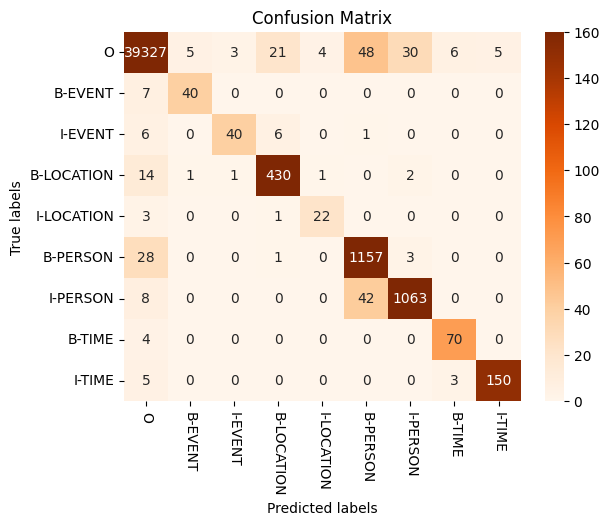

In [ ]:
get_confusion_matrix(df_test)

In [ ]:
get_misclassified_report(df_test, os.path.join(eval_dir, f"{experiment_name}-confidence-0.9-misclassified.xlsx"))

100%|██████████| 42558/42558 [00:01<00:00, 22321.32it/s]


In [ ]:
get_correct_and_incorrect_classification(df_test, f"{experiment_name}-iterative-6")

100%|██████████| 42558/42558 [02:26<00:00, 290.34it/s]


In [ ]:
df_test_base = pd.read_csv(os.path.join(dataset_dir, "test.csv"))
df_test_base["label"] = df_test_base["label"].apply(lambda x: x.replace("_", "-"))

get_predicted_label_on_test_dataset(
    model_path=os.path.join(model_dir , f"{experiment_name}-base"),
    df=df_test_base,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 258/258 [00:06<00:00, 40.20it/s]


In [ ]:
get_overall_performance(df_test_base)
get_individual_label_score(df_test_base)

Accuracy: 0.9920578974575873
Precision: 0.9923280915939552
Recall: 0.9920578974575873
F1 Score: 0.992129729399123


,precision,recall,f1-score,support
O,0.997917,0.995665,0.996790,39449.000000
B-EVENT,0.769231,0.851064,0.808081,47.000000
I-EVENT,0.833333,0.754717,0.792079,53.000000
B-LOCATION,0.929825,0.944321,0.937017,449.000000
I-LOCATION,0.954545,0.807692,0.875000,26.000000
B-PERSON,0.896605,0.977292,0.935211,1189.000000
I-PERSON,0.965961,0.943396,0.954545,1113.000000
B-TIME,0.807692,0.851351,0.828947,74.000000
I-TIME,0.893082,0.898734,0.895899,158.000000
accuracy,0.992058,0.992058,0.992058,0.992058
